# Application of WAVEGUISE to a timeseries from the Strateole-2 campaign
During the Strateole-2 campaign long-duration balloons equipped with a number of sensors was floating at equatorial latitudes. At an altitude of approximately 50hPa the balloon was sampling temperature, pressure, wind, humidity, etc. I'm investigating the pressure data and aim to separate periodic structures from gravity waves, tides, and planetary waves. Simultaneously, the spectral properties of the identified wave packets are extracted.

In [1]:
import sys
sys.path.append('/home/r/Robert.Reichert/juwavelet')
import juwavelet.transform as transform
from juwavelet import utils
sys.path.append('../scripts')
import utils_1D as one

import copy
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats, ndimage
import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.style.use("../latex_default.mplstyle")

/home/r/Robert.Reichert/.conda/envs/JuWavelet/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
ST2_path = '../data/ST2_C0_01_STR1_TSEN_v03b.nc'
ds = xr.open_dataset(ST2_path)
ds = ds.isel(time=slice(0,600*60*2))

/home/r/Robert.Reichert/.conda/envs/JuWavelet/lib/python3.12/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)


Text(0.5, 0, 'Time / UTC')

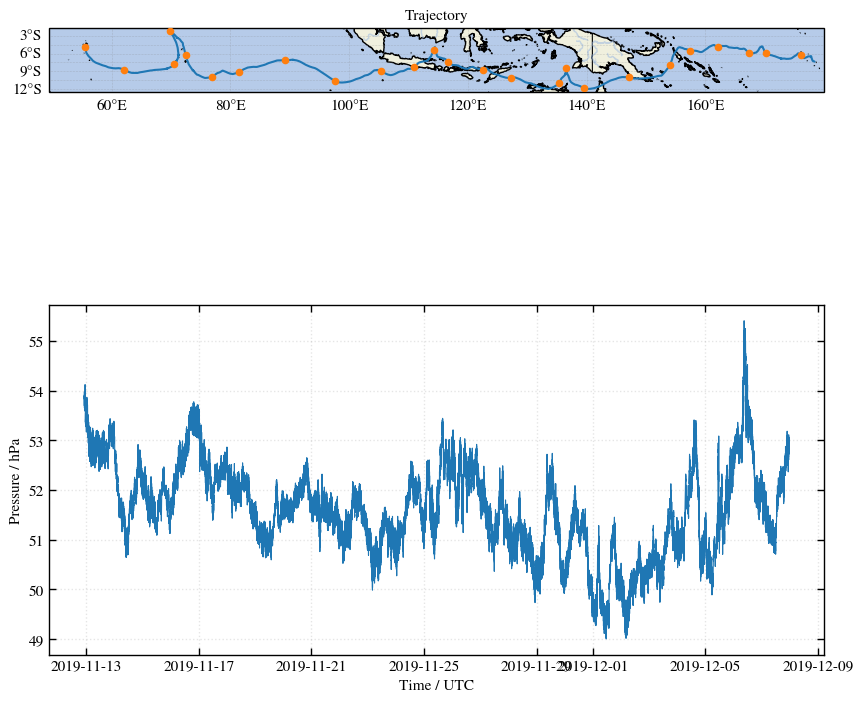

In [3]:
lons = ds['lon'].values
lats = ds['lat'].values

gskw = {"hspace": 0.06, "wspace": 0.05, "height_ratios": [1, 1]}
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(10, 10))

# --- Karten-Achse ---
ax_map = fig.add_subplot(2, 1, 1, projection=proj)

ax_map.add_feature(cfeature.LAND, alpha=0.9)
ax_map.add_feature(cfeature.OCEAN, alpha=0.7)
ax_map.add_feature(cfeature.COASTLINE, linewidth=1.0)
ax_map.add_feature(cfeature.BORDERS, linewidth=0.8)
ax_map.add_feature(cfeature.LAKES, alpha=0.6)
ax_map.add_feature(cfeature.RIVERS, alpha=0.5)

gl = ax_map.gridlines(draw_labels=True, linewidth=0.4, alpha=0.6)
gl.right_labels = False
gl.top_labels = False

ax_map.plot(lons, lats, transform=proj, linewidth=1.5)
ax_map.scatter(lons[::120*24], lats[::120*24], s=20, color="tab:orange", transform=proj, zorder=5)

ax_map.set_title("Trajectory")

# --- Pressure timeseries ---
ax_ts = fig.add_subplot(2, 1, 2)
ax_ts.plot(ds['time'], ds['pressure'])
ax_ts.set_ylabel("Pressure / hPa")
ax_ts.set_xlabel("Time / UTC")

Within 600 hours, the baloon was drifting from the Seychelles to over the Marshall Islands. The pressure measurements show a lot variability which arises from the superposition of multiple wave phenomena.

In [3]:
# Compute the wavelet transform
dt = 30/3_600
nt = len(ds['time'])
time = np.linspace(dt,nt*dt,nt)
orig = ds['pressure'].values
nmask  = orig.shape
ntap   = int(0.1*np.min(nmask))
signal = utils.smooth_edges(orig-np.mean(orig), ntap, window='tukey')

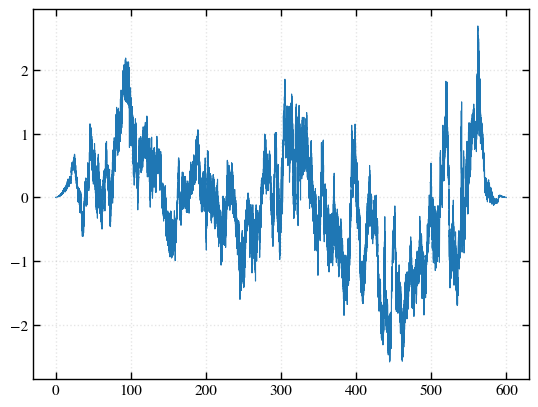

In [31]:
# Pre-processed data
plt.plot(time,signal)

In [4]:
s0 = 20*dt
dj = 1/8
js = int(1/dj*np.log2(nt*dt/s0))
cwt_result = transform.decompose1d(signal, dt, s0, dj, js, opts={'param': 2*np.pi}, mode="scaled", dtype=np.complex128)

(0.16666666666666666, 526.4079617392438)

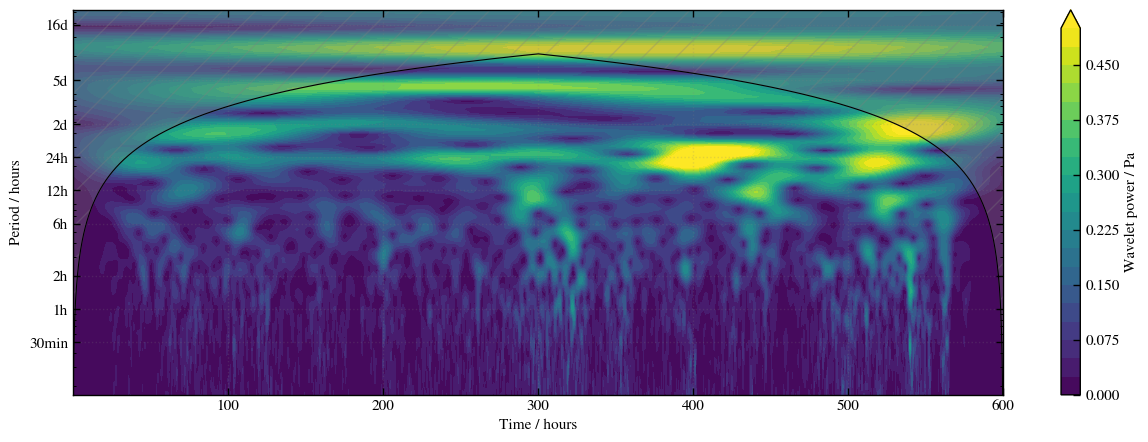

In [14]:
TIME, PERIOD = np.meshgrid(time, cwt_result["period"])
WPS = np.abs(cwt_result['decomposition'])

fig = plt.figure(figsize=(15, 5))
plt.contourf(TIME, PERIOD, WPS, levels=np.linspace(0,0.5,21), extend='max')
plt.colorbar(location="right", orientation="vertical", label="Wavelet power / Pa")
plt.yscale("log")
plt.xlabel("Time / hours")
plt.ylabel("Period / hours")
plt.yticks([0.5,1,2,6,12,24,48,5*24,16*24],['30min','1h','2h','6h','12h','24h','2d','5d','16d'])
ax = plt.gca()
one.plot_COI(time,2*np.pi,ax, y2=np.max(cwt_result['period']), hatch='/', color='grey', alpha=0.3)
plt.ylim([np.min(cwt_result['period']),np.max(cwt_result['period'])])

There are many peaks in the wavelet spectrum. In order to reduce the number of identified wave packets I define a noise threshold under which wavelet coefficients are set to zero.

In [5]:
noise_floor = 0.1
cwt_copy   = copy.deepcopy(cwt_result)
WPS        = np.abs(cwt_copy['decomposition'])
mask       = WPS < noise_floor
cwt_copy['decomposition'][mask] = 0

### Segmentation

In [6]:
WPS = np.abs(cwt_copy['decomposition'])
_seg = one.wavefield_segmentation_1d(WPS,noise_floor,connectivity_order=2)
print(np.max(_seg))
seg = one.update_segments(WPS,_seg,threshold=0.95,mode='sum')
print(np.max(seg))

74
9


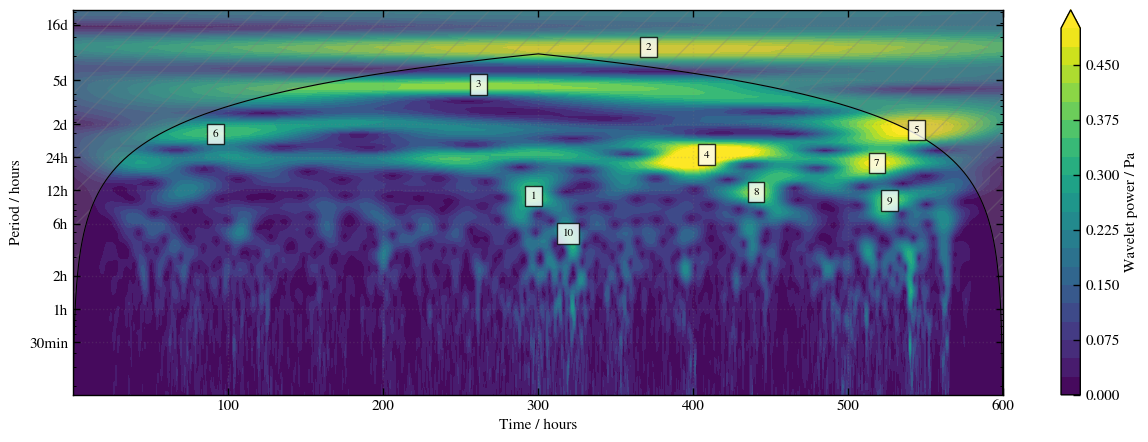

In [15]:
fig = plt.figure(figsize=(15, 5))
plt.contourf(TIME, PERIOD, WPS, levels=np.linspace(0,0.5,21), extend='max')
plt.colorbar(location="right", orientation="vertical", label="Wavelet power / Pa")
plt.yscale("log")
plt.xlabel("Time / hours")
plt.ylabel("Period")
plt.yticks([0.5,1,2,6,12,24,48,5*24,16*24],['30min','1h','2h','6h','12h','24h','2d','5d','16d'])
ax = plt.gca()
one.plot_COI(time,2*np.pi,ax, y2=np.max(cwt_result['period']), hatch='/', color='grey', alpha=0.3)
plt.ylim([np.min(cwt_result['period']),np.max(cwt_result['period'])])

for lab in np.unique(seg):
    mask     = (seg == lab)
    if not np.any(mask):
        continue
    flat_idx = np.argmax(np.where(mask, WPS, -np.inf))
    iy, ix   = np.unravel_index(flat_idx, WPS.shape)
    center_x = TIME[iy, ix]
    center_y = PERIOD[iy, ix]
    plt.text(center_x,center_y,str(lab+1),color="k",fontsize=8,ha="center",va="center",bbox=dict(facecolor="white", alpha=0.8))

In [7]:
recon_seg = one.recon_segments_1d(cwt_copy,seg,time)

Text(0.5, 0, 'Time / h')

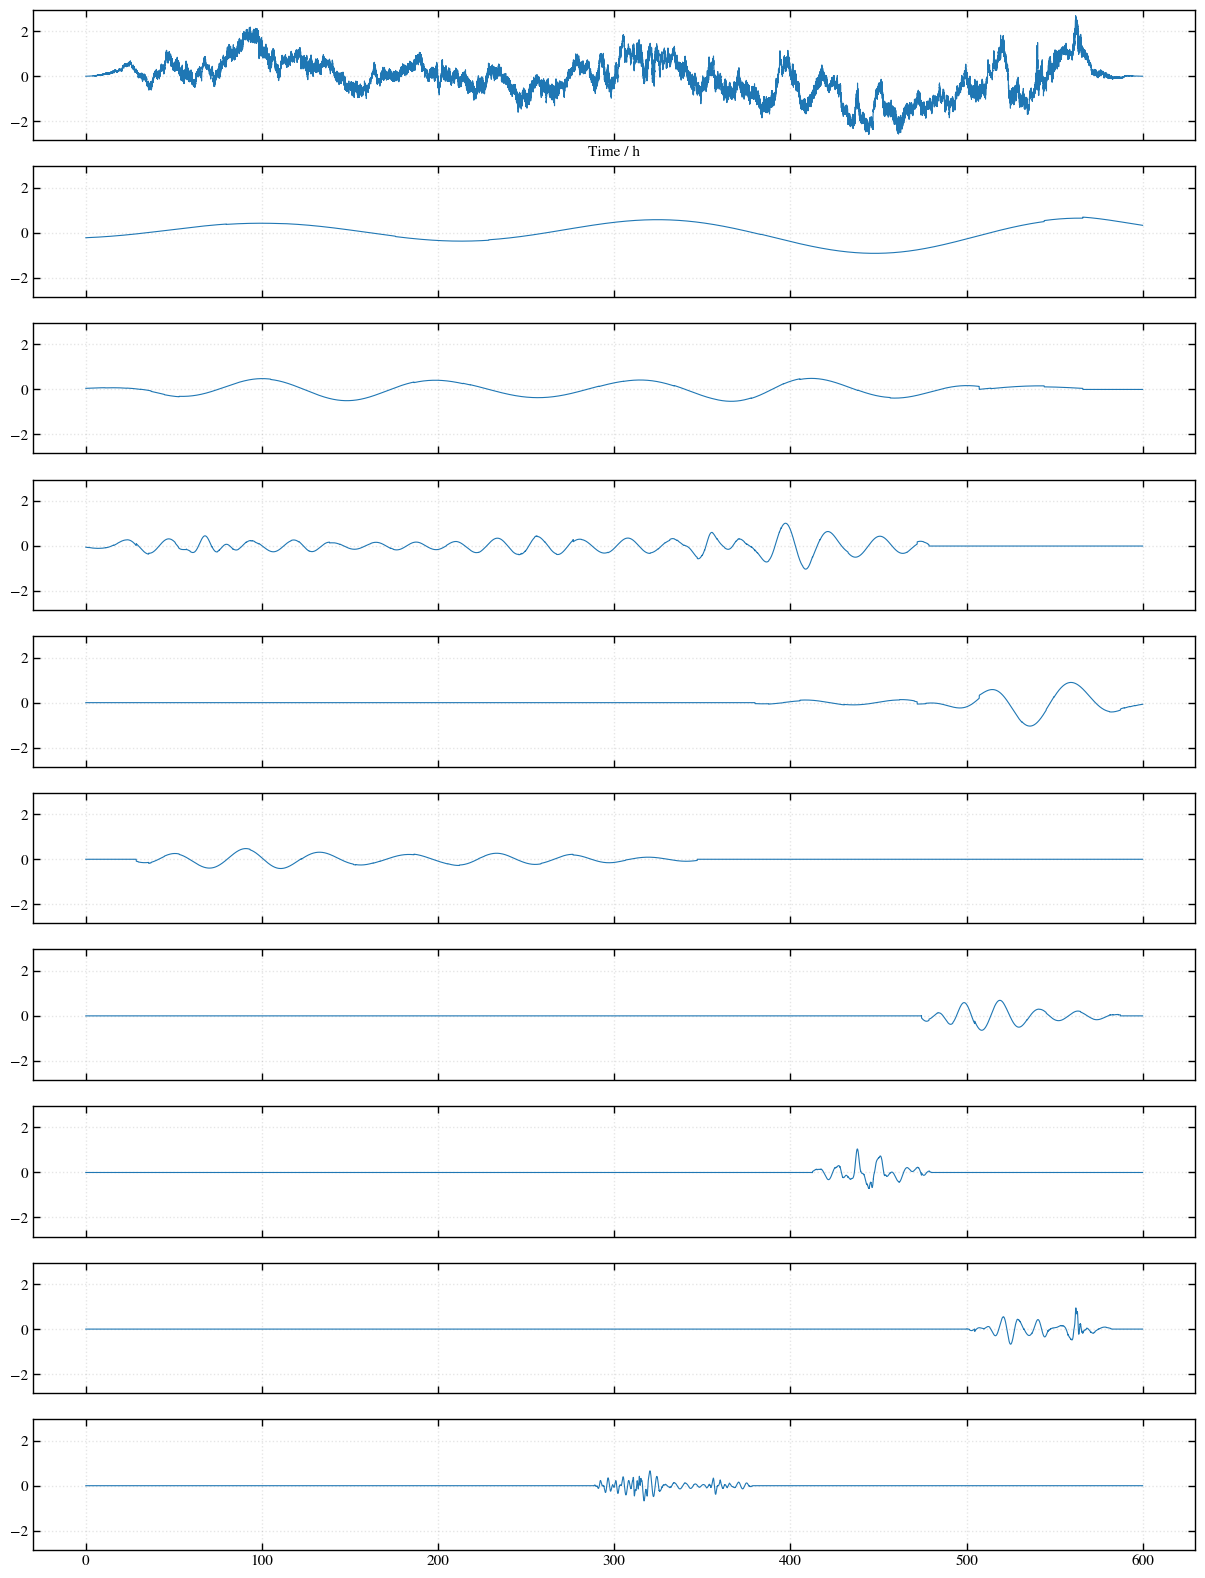

In [9]:
fig, ax=plt.subplots(recon_seg.shape[0]+1,1, figsize=(15,20), sharex=True, sharey=True)
ax[0].plot(time, signal)

for i in range(1,recon_seg.shape[0]+1):
    ax[i].plot(time,recon_seg[i-1])
ax[0].set_xlabel('Time / h')

Text(0.5, 0, 'Time / h')

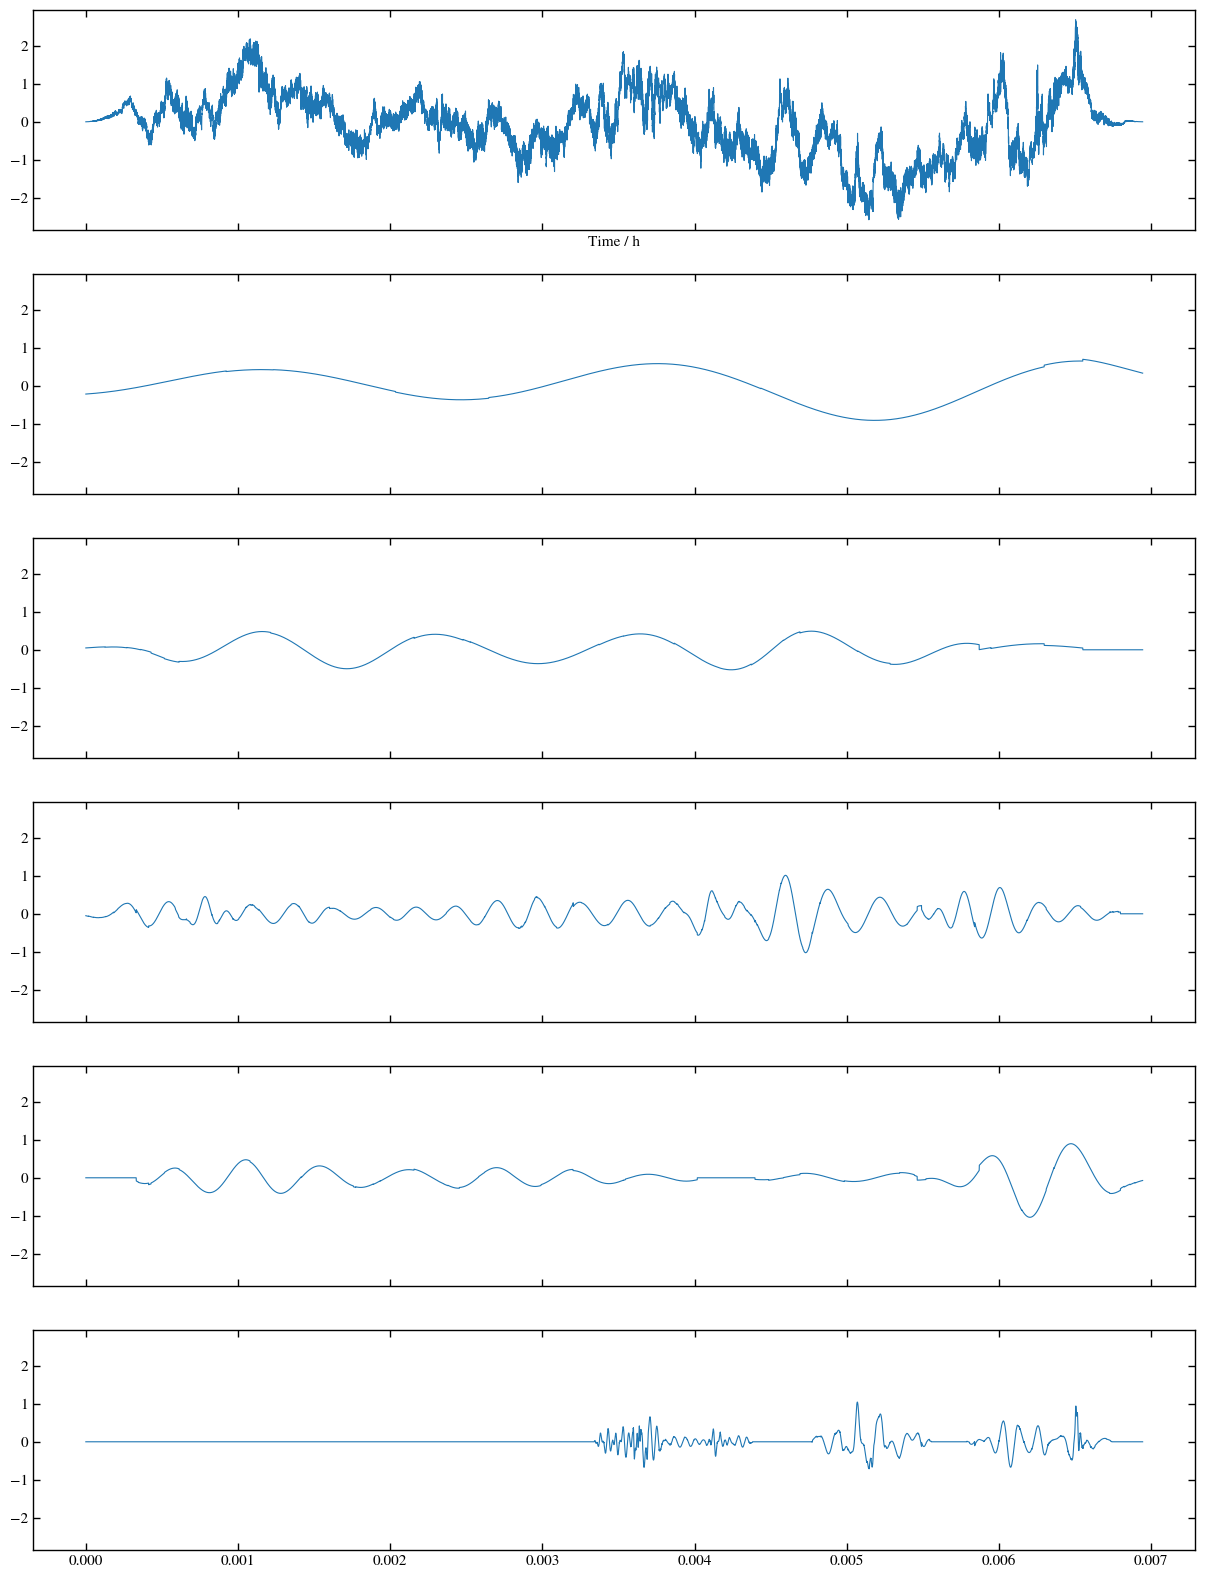

In [12]:
fig, ax=plt.subplots(6,1, figsize=(15,20), sharex=True, sharey=True)
ax[0].plot(time/3_600/24, signal)
ax[1].plot(time/3_600/24,recon_seg[0])
ax[2].plot(time/3_600/24,recon_seg[1])
ax[3].plot(time/3_600/24,recon_seg[2]+recon_seg[5])
ax[4].plot(time/3_600/24,recon_seg[3]+recon_seg[4])
ax[5].plot(time/3_600/24,recon_seg[6]+recon_seg[7]+recon_seg[8])

ax[0].grid(which='both')
ax[1].grid(which='both')
ax[2].grid(which='both')
ax[3].grid(which='both')
ax[4].grid(which='both')
ax[5].grid(which='both')
ax[0].set_xlabel('Time / h')